# K-Nearest Neighbors (KNN) from Scratch

**K-Nearest Neighbors (KNN)** is a simple algorithm used for **classification** — predicting which category (class) a data point belongs to.

The idea is intuitive: to classify a new point, look at the **k closest points** in the training data, and assign the **majority class** among them.

KNN doesn't really "train" in the traditional sense — there's no fitting of weights. It simply **stores the training data** and does all the work at prediction time, by measuring distances to that stored data.

The animation below shows this process: a new point is compared to nearby data points, its `k` nearest neighbors are found, and it's classified based on their majority vote.

![KNN Animation]![Decision Tree Animation](../GIF/knn.gif)

## 1. Load the Data

We start by loading the dataset.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('../Data_SET/Social_Network_Ads.csv')
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


**About this dataset:** it has two input features, `Age` and `EstimatedSalary`, and one target variable, `Purchased`, which is binary (0 = did not purchase, 1 = purchased).
Since the target has a fixed set of categories, this is a **binary classification problem**.

## 2. Select Features and Target

In [3]:
X = df[['Age', 'EstimatedSalary']].values   # input features
y = df['Purchased'].values                   # target variable (0 or 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 2)
y shape: (400,)


## 3. Train/Test Split (Manual)

We split the data into a **training set** (used as the reference points KNN compares against) and a **test set** (used to check how well it classifies new points). We do this manually by shuffling the row indices and slicing them 80/20.

In [4]:
np.random.seed(42)  # for reproducible results

n_samples = X.shape[0]
indices = np.arange(n_samples)
np.random.shuffle(indices)

split_point = int(0.8 * n_samples)
train_idx, test_idx = indices[:split_point], indices[split_point:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 320
Test samples: 80


## 4. Feature Scaling

We standardize the features so each has a mean of 0 and a standard deviation of 1:

$$X_{scaled} = \frac{X - mean}{std}$$

This matters a lot for KNN specifically: since it classifies points based on **distance**, a feature with a much larger range (like `EstimatedSalary`, in the tens of thousands) would completely dominate the distance calculation over a smaller-range feature (like `Age`). Scaling puts both features on equal footing.

As before, we compute the mean/std **only from the training set**, then apply it to both sets.

In [5]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

## 5. KNN From Scratch

Now we implement KNN using only NumPy. For each point we want to classify, the algorithm:

1. Computes the **Euclidean distance** to every training point: $\text{distance} = \sqrt{\sum (x_1 - x_2)^2}$
2. Finds the **k nearest** training points (smallest distances).
3. Takes a **majority vote** among their labels to predict the class.

There's no training loop here — the "model" is just the stored training data plus these two steps.

In [6]:
class KNNClassifier:
    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        # KNN doesn't learn parameters — it just stores the data
        self.X_train = X
        self.y_train = y

    def _euclidean_distance(self, point):
        # Distance from one point to every training point
        return np.sqrt(np.sum((self.X_train - point) ** 2, axis=1))

    def predict(self, X):
        predictions = []
        for point in X:
            # 1. Distance to every training point
            distances = self._euclidean_distance(point)

            # 2. Indices of the k smallest distances (nearest neighbors)
            nearest_idx = np.argsort(distances)[:self.k]
            nearest_labels = self.y_train[nearest_idx]

            # 3. Majority vote among the neighbors' labels
            values, counts = np.unique(nearest_labels, return_counts=True)
            predicted_class = values[np.argmax(counts)]
            predictions.append(predicted_class)

        return np.array(predictions)

## 6. Making Predictions

We fit the classifier (which simply stores the training data) with `k=5`, then predict labels for the test set.

In [7]:
knn = KNNClassifier(k=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

for actual, predicted in zip(y_test, y_pred):
    print(f"Actual: {actual}   Predicted: {predicted}")

Actual: 0   Predicted: 1
Actual: 0   Predicted: 0
Actual: 1   Predicted: 1
Actual: 0   Predicted: 0
Actual: 1   Predicted: 1
Actual: 1   Predicted: 1
Actual: 1   Predicted: 0
Actual: 0   Predicted: 0
Actual: 0   Predicted: 0
Actual: 0   Predicted: 0
Actual: 0   Predicted: 0
Actual: 0   Predicted: 0
Actual: 0   Predicted: 0
Actual: 0   Predicted: 0
Actual: 1   Predicted: 1
Actual: 0   Predicted: 0
Actual: 0   Predicted: 0
Actual: 0   Predicted: 0
Actual: 0   Predicted: 0
Actual: 0   Predicted: 0
Actual: 0   Predicted: 1
Actual: 0   Predicted: 0
Actual: 0   Predicted: 0
Actual: 0   Predicted: 1
Actual: 1   Predicted: 1
Actual: 0   Predicted: 0
Actual: 0   Predicted: 0
Actual: 1   Predicted: 1
Actual: 0   Predicted: 0
Actual: 0   Predicted: 0
Actual: 1   Predicted: 0
Actual: 0   Predicted: 0
Actual: 1   Predicted: 1
Actual: 0   Predicted: 0
Actual: 1   Predicted: 1
Actual: 1   Predicted: 1
Actual: 0   Predicted: 0
Actual: 0   Predicted: 1
Actual: 1   Predicted: 1
Actual: 0   Predicted: 0


Each prediction comes from a **majority vote**: whichever class appears most often among the 5 nearest neighbors wins. The choice of `k` matters — a **small k** (e.g. 1) makes the model very sensitive to noise and outliers, while a **large k** produces a smoother, more stable decision but can blur the boundary between classes.

## 7. Model Evaluation

We evaluate the predictions using:

- **Accuracy**: the proportion of correct predictions.
- **Confusion Matrix**: counts of True Positives, True Negatives, False Positives, and False Negatives.

In [8]:
accuracy = np.sum(y_pred == y_test) / len(y_test)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8875


In [9]:
# Simple confusion matrix (class 1 = "Purchased" is treated as positive)
tp = np.sum((y_pred == 1) & (y_test == 1))
tn = np.sum((y_pred == 0) & (y_test == 0))
fp = np.sum((y_pred == 1) & (y_test == 0))
fn = np.sum((y_pred == 0) & (y_test == 1))

print("Confusion Matrix")
print(f"True Positives:  {tp}")
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")

Confusion Matrix
True Positives:  22
True Negatives:  49
False Positives: 6
False Negatives: 3


## 8. Visualizing the Decision Boundary

Since we only have two features, we can visualize how KNN divides the feature space into regions. We predict the class over a fine grid of points and color each region accordingly, then overlay the actual training data.

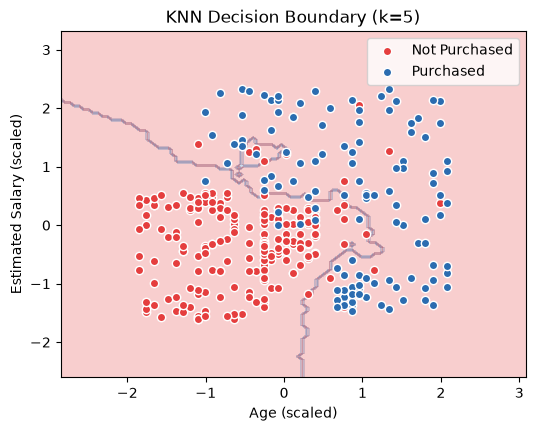

In [10]:
# Build a grid covering the scaled feature space
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                      np.linspace(y_min, y_max, 100))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Predict the class for every point in the grid (this defines the decision boundary)
grid_preds = knn.predict(grid_points).reshape(xx.shape)

plt.figure(figsize=(6, 4.5))
plt.contourf(xx, yy, grid_preds, alpha=0.25, colors=['#e53e3e', '#2b6cb0'])

for cls, color, label in [(0, '#e53e3e', 'Not Purchased'), (1, '#2b6cb0', 'Purchased')]:
    mask = y_train == cls
    plt.scatter(X_train_scaled[mask, 0], X_train_scaled[mask, 1],
                color=color, edgecolor='white', label=label)

plt.xlabel('Age (scaled)')
plt.ylabel('Estimated Salary (scaled)')
plt.title(f'KNN Decision Boundary (k={knn.k})')
plt.legend()
plt.show()

## Conclusion

- **KNN** classifies a new point by looking at the `k` closest points in the training data and taking a **majority vote** of their labels.
- It doesn't fit parameters like other models — it simply stores the training data and does the work at prediction time.
- **Feature scaling** matters because KNN relies on distance, so features with larger ranges would otherwise unfairly dominate the result.
- The choice of **k** controls the trade-off between sensitivity to noise (small k) and a smoother decision boundary (large k).